# Physics-Informed Neural Networks (PINNs): 1D Heat Equation, Inverse Diffusion, and Burgers' Equation

<div align="center">
    <a href="https://colab.research.google.com/github/sergey-gusev94/pinn/blob/main/pinn_notebook.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
</div>

This notebook is a **self-contained educational introduction** to physics-informed neural networks (PINNs). It uses three linked examples:

1. **Forward problem:** solve the 1D heat equation with known diffusion coefficient  
2. **Inverse problem:** infer the diffusion coefficient from sparse observations  
3. **Nonlinear extension:** solve Burgers' equation


The structure follows the original PINN framing of **forward** and **inverse** problems introduced by Raissi, Perdikaris, and Karniadakis in *Physics Informed Deep Learning (Part I)*: [arXiv:1711.10561](https://arxiv.org/abs/1711.10561). The inverse-diffusion and Burgers setups are also closely related to standard tutorial examples in DeepXDE, while a lightweight ODE-style warmup for the overall workflow can be found in the SciML / NeuralPDE documentation.

## What you will see
- How the PINN loss is built from **physics residuals**, **boundary conditions**, **initial conditions**, and optionally **data**
- How **automatic differentiation** produces PDE derivatives
- How **collocation points** are sampled inside a space-time domain
- Why PINNs are often especially compelling for **inverse problems**
- Why Burgers' equation is a natural next step after the heat equation



## Recommended background and references

These links are included **for specific reasons**, not just as a bibliography. If you want to know what each resource is contributing to this notebook, use them as follows:

1. **Original PINN paper**  
   M. Raissi, P. Perdikaris, G. E. Karniadakis, *Physics Informed Deep Learning (Part I): Data-driven Solutions of Nonlinear Partial Differential Equations*, 2017.  
   [https://arxiv.org/abs/1711.10561](https://arxiv.org/abs/1711.10561)  
   Use this for the **core idea** of PINNs: forward problems, inverse problems, residual-based losses, and the overall conceptual framing.

2. **DeepXDE inverse diffusion tutorial**  
   [https://deepxde.readthedocs.io/en/latest/demos/pinn_inverse/diffusion.1d.inverse.html](https://deepxde.readthedocs.io/en/latest/demos/pinn_inverse/diffusion.1d.inverse.html)  
   Use this to compare this notebook's inverse-diffusion setup with a **high-level PINN framework** implementation.

3. **DeepXDE Burgers tutorial**  
   [https://deepxde.readthedocs.io/en/stable/demos/pinn_forward/burgers.html](https://deepxde.readthedocs.io/en/stable/demos/pinn_forward/burgers.html)  
   Use this as a reference for a **standard nonlinear benchmark problem** in PINNs.

4. **NeuralPDE ODE tutorial**  
   [https://docs.sciml.ai/NeuralPDE/stable/tutorials/ode/](https://docs.sciml.ai/NeuralPDE/stable/tutorials/ode/)  
   Use this if you want a very compact example of the general PINN workflow in a simpler differential-equation setting.

5. **Recent review / perspective**  
   M. Raissi et al., *Physics-Informed Neural Networks and Extensions*, 2024.  
   [https://arxiv.org/abs/2408.16806](https://arxiv.org/abs/2408.16806)  
   Use this for **modern context**: extensions, limitations, and how the field has evolved.

6. **A useful cautionary comparison with finite elements**  
   T. Grossmann et al., *Can physics-informed neural networks beat the finite element method?*, 2024.  
   [https://academic.oup.com/imamat/article/89/1/143/7680268](https://academic.oup.com/imamat/article/89/1/143/7680268)  
   Use this as a reality check. PINNs are flexible and elegant, but they are not automatically the best tool for standard forward PDE solves.

This notebook uses those sources for **conceptual framing and tutorial alignment**, but all implementations below are written directly in **PyTorch** for transparency.


## Note about specialized PINN packages

Yes, there **are** packages that make PINNs easier to implement.

Examples:
- **DeepXDE**: [documentation](https://deepxde.readthedocs.io/)
- **NeuralPDE.jl**: [documentation](https://docs.sciml.ai/NeuralPDE/stable/)
- **NVIDIA PhysicsNeMo Sym**: [documentation](https://docs.nvidia.com/deeplearning/physicsnemo/physicsnemo-sym/)


These tools can simplify many parts of the workflow:
- domain and geometry definitions
- boundary and initial condition specification
- collocation-point generation
- optimizer setups and training loops
- built-in demos for standard PDEs

So why not use them here?

Because for an **educational notebook**, it is often better to implement the core pieces manually at least once. That way you can see:
- where the residual $r_\theta$ comes from,
- how automatic differentiation produces $u_t$, $u_x$, and $u_{xx}$,
- how the different loss terms are assembled,
- and what changes when you move from a forward problem to an inverse problem.

After that, higher-level libraries become much easier to understand and use correctly.

However, in real work you will most likely want to use a specialized PINN package/framework to move faster and avoid re-implementing a lot of tooling.


## Before you run the notebook

A few practical notes:

- The heat-equation and inverse-diffusion sections are usually the easiest to train.
- The Burgers section is harder and may need more epochs for sharper results.
- Results will vary somewhat with random initialization and hardware.
- On CPU, training may take a while. On GPU, it should be noticeably faster.
- If the notebook feels slow, the first parameters to reduce are:
  - `epochs`
  - `n_f` (number of interior collocation points)
  - network width / depth

If the notebook runs but the results look rough, common improvements are:
- increase epochs,
- increase collocation points,
- try Adam followed by L-BFGS,
- tune loss weights,
- or normalize / nondimensionalize the inputs more carefully.

Those are all standard practical issues in PINNs and are part of why modern PINN papers spend so much effort on training strategy.


In [2]:
# If you need packages, uncomment the next line and run it once.
# !pip install numpy matplotlib scipy torch

# We intentionally use only general-purpose scientific Python tools here.
# Frameworks such as DeepXDE, NeuralPDE.jl, and Modulus can automate much of
# the PINN workflow, but for educational purposes we build the core pieces ourselves.

import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def to_numpy(t):
    return t.detach().cpu().numpy()

def mse(a, b):
    return torch.mean((a - b) ** 2)

def make_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def meshgrid_eval(xmin, xmax, tmin, tmax, nx=200, nt=200):
    x = np.linspace(xmin, xmax, nx)
    t = np.linspace(tmin, tmax, nt)
    X, T = np.meshgrid(x, t)
    XT = np.column_stack([X.ravel(), T.ravel()])
    return x, t, X, T, XT

def plot_heatmap(X, T, Z, title, xlabel="x", ylabel="t", cmap="viridis"):
    plt.figure(figsize=(7.5, 5))
    plt.pcolormesh(X, T, Z, shading="auto", cmap=cmap)
    plt.colorbar()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

def plot_line_slices(x, exact_grid, pred_grid, t_values, t_grid, title_prefix):
    plt.figure(figsize=(8, 5))
    for t0 in t_values:
        idx = np.argmin(np.abs(t_grid - t0))
        plt.plot(x, exact_grid[idx], label=f"Exact / ref, t={t_grid[idx]:.2f}")
        plt.plot(x, pred_grid[idx], "--", label=f"PINN, t={t_grid[idx]:.2f}")
    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.title(title_prefix)
    plt.legend(ncol=2, fontsize=9)
    plt.show()

def plot_losses(history, title="Training losses"):
    plt.figure(figsize=(8, 5))
    for key, values in history.items():
        plt.plot(values, label=key)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

def sample_uniform(n, low, high):
    return np.random.uniform(low, high, size=(n, 1))

def scatter_training_points(x_ic, t_ic, x_bc, t_bc, x_f, t_f, title):
    plt.figure(figsize=(7.5, 5))
    plt.scatter(x_f, t_f, s=8, alpha=0.25, label="Interior collocation")
    plt.scatter(x_ic, t_ic, s=18, label="Initial-condition points")
    plt.scatter(x_bc, t_bc, s=18, label="Boundary-condition points")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(title)
    plt.legend()
    plt.show()

## 1. What is a PINN?

A PINN approximates the unknown solution $u(x,t)$ with a neural network $u_\theta(x,t)$.  
Instead of training only on labeled data, it also penalizes violations of the governing differential equation.

For a PDE written abstractly as

$$
\mathcal{N}[u](x,t)=0,
$$

we define a neural approximation $u_\theta(x,t)$ and a **physics residual**

$$
r_\theta(x,t)=\mathcal{N}[u_\theta](x,t).
$$

The loss usually combines several pieces:

$$
\mathcal{L}=
\lambda_{\text{res}}\mathcal{L}_{\text{res}}
+\lambda_{\text{bc}}\mathcal{L}_{\text{bc}}
+\lambda_{\text{ic}}\mathcal{L}_{\text{ic}}
+\lambda_{\text{data}}\mathcal{L}_{\text{data}}.
$$

- $\mathcal{L}_{\text{res}}$: enforce the PDE in the interior of the domain  
- $\mathcal{L}_{\text{bc}}$: enforce boundary conditions  
- $\mathcal{L}_{\text{ic}}$: enforce initial conditions  
- $\mathcal{L}_{\text{data}}$: fit observed measurements when they exist

This residual-based construction is the central idea in the original PINN paper by Raissi et al.  
Reference used here for the conceptual setup: [arXiv:1711.10561](https://arxiv.org/abs/1711.10561)

### Why automatic differentiation matters

Because the model $u_\theta(x,t)$ is a differentiable neural network, we can compute derivatives such as

$$
u_t,\quad u_x,\quad u_{xx}
$$

using **automatic differentiation** rather than finite differences. That is what makes it straightforward to build PDE residuals directly inside the training loop.


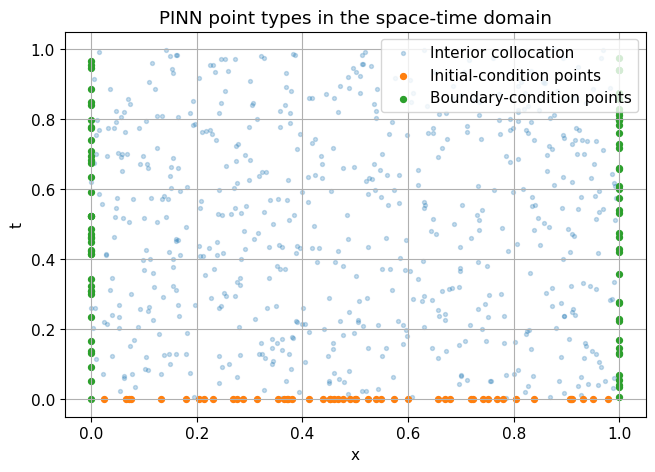

In [4]:
n_ic_demo = 50
n_bc_demo = 80
n_f_demo = 600

x_ic_demo = sample_uniform(n_ic_demo, 0.0, 1.0)
t_ic_demo = np.zeros_like(x_ic_demo)

t_bc_left = sample_uniform(n_bc_demo // 2, 0.0, 1.0)
x_bc_left = np.zeros_like(t_bc_left)

t_bc_right = sample_uniform(n_bc_demo // 2, 0.0, 1.0)
x_bc_right = np.ones_like(t_bc_right)

x_bc_demo = np.vstack([x_bc_left, x_bc_right])
t_bc_demo = np.vstack([t_bc_left, t_bc_right])

x_f_demo = sample_uniform(n_f_demo, 0.0, 1.0)
t_f_demo = sample_uniform(n_f_demo, 0.0, 1.0)

scatter_training_points(
    x_ic_demo, t_ic_demo,
    x_bc_demo, t_bc_demo,
    x_f_demo, t_f_demo,
    "PINN point types in the space-time domain"
)

## 2. Example A: forward PINN for the 1D heat equation

We start with the classical 1D heat equation


$$
u_t = \alpha u_{xx}, \qquad x \in [0,1], \ t \in [0,1],
$$


with homogeneous Dirichlet boundary conditions


$$
u(0,t)=0,\qquad u(1,t)=0,
$$


and initial condition


$$
u(x,0)=\sin(\pi x).
$$


For this setup, the exact solution is


$$
u(x,t)=e^{-\alpha \pi^2 t}\sin(\pi x).
$$


This makes it an ideal teaching example because:
- the PDE residual is simple,
- the exact solution is known,
- the plots are easy to interpret,
- the same setup extends naturally to the inverse problem.


Related turotial examples : [DeepXDE inverse diffusion tutorial](https://deepxde.readthedocs.io/en/latest/demos/pinn_inverse/diffusion.1d.inverse.html),  [DeepXDE heat equation tutorial](https://deepxde.readthedocs.io/en/stable/demos/pinn_forward/heat.html)

In [5]:
@dataclass
class HeatConfig:
    alpha: float = 0.10
    xmin: float = 0.0
    xmax: float = 1.0
    tmin: float = 0.0
    tmax: float = 1.0
    n_ic: int = 100
    n_bc: int = 100
    n_f: int = 2000
    hidden_width: int = 64
    hidden_layers: int = 3
    epochs: int = 2000
    lr: float = 1e-3

heat_cfg = HeatConfig()
heat_cfg

HeatConfig(alpha=0.1, xmin=0.0, xmax=1.0, tmin=0.0, tmax=1.0, n_ic=100, n_bc=100, n_f=2000, hidden_width=64, hidden_layers=3, epochs=2000, lr=0.001)

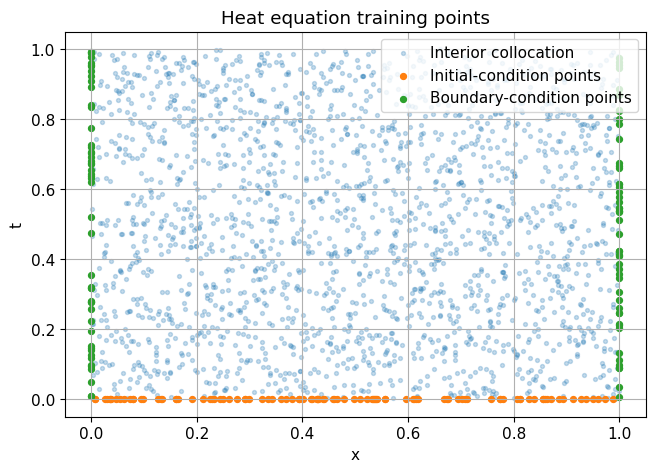

In [6]:
def exact_heat_solution(x, t, alpha):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

def generate_heat_training_data(cfg):
    x_ic = sample_uniform(cfg.n_ic, cfg.xmin, cfg.xmax)
    t_ic = np.zeros_like(x_ic)
    u_ic = exact_heat_solution(x_ic, t_ic, cfg.alpha)

    n_half = cfg.n_bc // 2
    t_bc_l = sample_uniform(n_half, cfg.tmin, cfg.tmax)
    x_bc_l = np.zeros_like(t_bc_l)
    u_bc_l = np.zeros_like(t_bc_l)

    t_bc_r = sample_uniform(cfg.n_bc - n_half, cfg.tmin, cfg.tmax)
    x_bc_r = np.ones_like(t_bc_r) * cfg.xmax
    u_bc_r = np.zeros_like(t_bc_r)

    x_bc = np.vstack([x_bc_l, x_bc_r])
    t_bc = np.vstack([t_bc_l, t_bc_r])
    u_bc = np.vstack([u_bc_l, u_bc_r])

    x_f = sample_uniform(cfg.n_f, cfg.xmin, cfg.xmax)
    t_f = sample_uniform(cfg.n_f, cfg.tmin, cfg.tmax)

    return {
        "x_ic": x_ic, "t_ic": t_ic, "u_ic": u_ic,
        "x_bc": x_bc, "t_bc": t_bc, "u_bc": u_bc,
        "x_f": x_f, "t_f": t_f,
    }

heat_data = generate_heat_training_data(heat_cfg)
scatter_training_points(
    heat_data["x_ic"], heat_data["t_ic"],
    heat_data["x_bc"], heat_data["t_bc"],
    heat_data["x_f"], heat_data["t_f"],
    "Heat equation training points"
)

In [7]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, width=64, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def gradients(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]

def heat_residual(model, xt, alpha):
    xt.requires_grad_(True)
    u = model(xt)
    grads = gradients(u, xt)
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]
    u_xx = gradients(u_x, xt)[:, 0:1]
    return u_t - alpha * u_xx

def make_xt(x, t):
    return make_tensor(np.hstack([x, t]))

### Loss terms for the heat equation

For the forward heat PINN we use


$$
r_\theta(x,t)=u_t - \alpha u_{xx},
$$


and define


$$
\mathcal{L}_{ic} = \frac{1}{N_{ic}}\sum_i \left(u_\theta(x_i,0)-\sin(\pi x_i)\right)^2,
$$



$$
\mathcal{L}_{bc} = \frac{1}{N_{bc}}\sum_i \left(u_\theta(0,t_i)-0\right)^2
+ \frac{1}{N_{bc}}\sum_i \left(u_\theta(1,t_i)-0\right)^2,
$$



$$
\mathcal{L}_{res} = \frac{1}{N_f}\sum_i r_\theta(x_i,t_i)^2.
$$


Then the total loss is


$$
\mathcal{L} = \mathcal{L}_{ic} + \mathcal{L}_{bc} + \mathcal{L}_{res}.
$$


This is the standard residual-based PINN structure from the original PINN formulation from [arXiv:1711.10561](https://arxiv.org/abs/1711.10561)

In [8]:
def train_heat_pinn(cfg, data):
    model = MLP(width=cfg.hidden_width, depth=cfg.hidden_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    xt_ic = make_xt(data["x_ic"], data["t_ic"])
    u_ic = make_tensor(data["u_ic"])

    xt_bc = make_xt(data["x_bc"], data["t_bc"])
    u_bc = make_tensor(data["u_bc"])

    xt_f = make_xt(data["x_f"], data["t_f"])

    history = {"total": [], "residual": [], "ic": [], "bc": []}

    for epoch in range(cfg.epochs):
        opt.zero_grad()

        pred_ic = model(xt_ic)
        pred_bc = model(xt_bc)
        r = heat_residual(model, xt_f.clone(), cfg.alpha)

        loss_ic = mse(pred_ic, u_ic)
        loss_bc = mse(pred_bc, u_bc)
        loss_res = torch.mean(r**2)
        loss = loss_ic + loss_bc + loss_res

        loss.backward()
        opt.step()

        history["total"].append(loss.item())
        history["residual"].append(loss_res.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())

        if (epoch + 1) % 250 == 0:
            print(
                f"Epoch {epoch+1:5d} | total={loss.item():.3e} | "
                f"res={loss_res.item():.3e} | ic={loss_ic.item():.3e} | bc={loss_bc.item():.3e}"
            )

    return model, history

heat_model, heat_history = train_heat_pinn(heat_cfg, heat_data)

Epoch   250 | total=2.420e-03 | res=1.447e-03 | ic=4.330e-04 | bc=5.395e-04
Epoch   500 | total=2.955e-04 | res=2.255e-04 | ic=2.038e-05 | bc=4.961e-05
Epoch   750 | total=1.001e-04 | res=7.699e-05 | ic=4.586e-06 | bc=1.850e-05
Epoch  1000 | total=7.071e-05 | res=5.319e-05 | ic=2.859e-06 | bc=1.466e-05
Epoch  1250 | total=5.596e-05 | res=4.075e-05 | ic=2.458e-06 | bc=1.275e-05
Epoch  1500 | total=4.500e-05 | res=3.207e-05 | ic=2.036e-06 | bc=1.090e-05
Epoch  1750 | total=3.645e-05 | res=2.594e-05 | ic=1.648e-06 | bc=8.867e-06
Epoch  2000 | total=2.995e-05 | res=2.169e-05 | ic=1.281e-06 | bc=6.980e-06


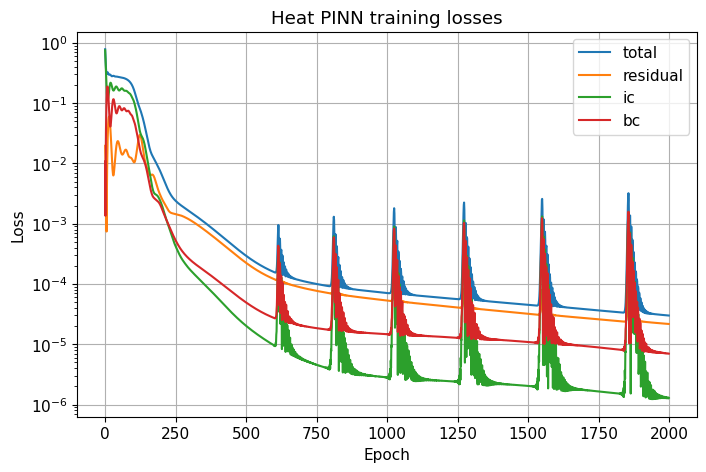

In [9]:
plot_losses(heat_history, title="Heat PINN training losses")

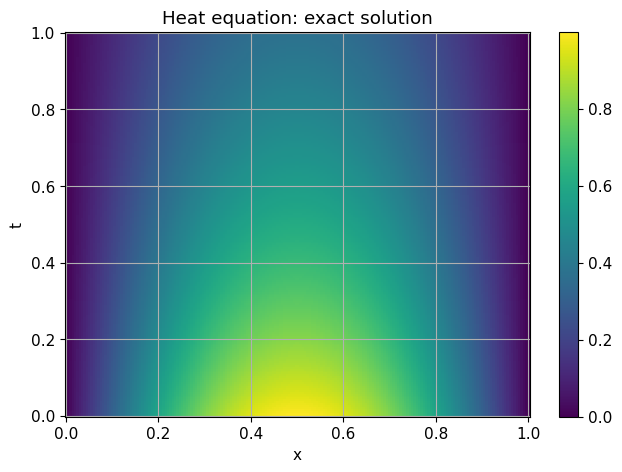

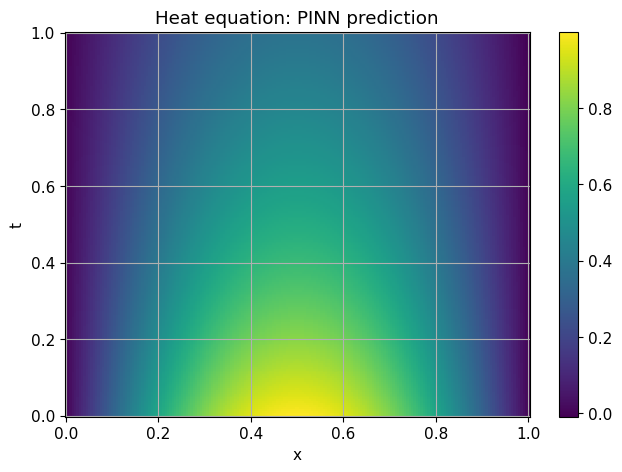

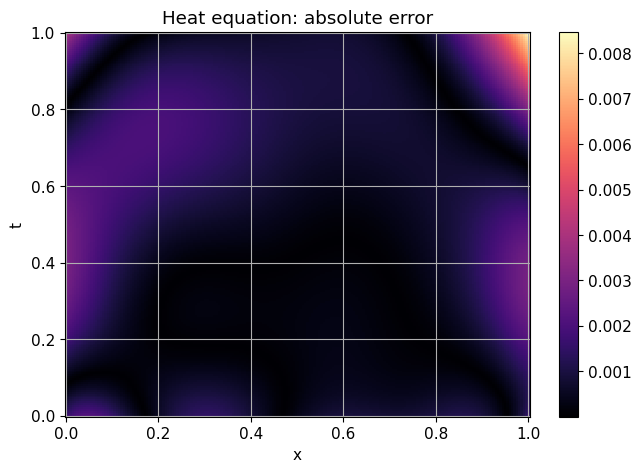

In [10]:
x_h, t_h, X_h, T_h, XT_h = meshgrid_eval(
    heat_cfg.xmin, heat_cfg.xmax,
    heat_cfg.tmin, heat_cfg.tmax,
    nx=200, nt=200
)

XT_h_t = make_tensor(XT_h)
with torch.no_grad():
    U_pred_h = to_numpy(heat_model(XT_h_t)).reshape(T_h.shape)

U_exact_h = exact_heat_solution(X_h, T_h, heat_cfg.alpha)
U_err_h = np.abs(U_pred_h - U_exact_h)

plot_heatmap(X_h, T_h, U_exact_h, "Heat equation: exact solution")
plot_heatmap(X_h, T_h, U_pred_h, "Heat equation: PINN prediction")
plot_heatmap(X_h, T_h, U_err_h, "Heat equation: absolute error", cmap="magma")

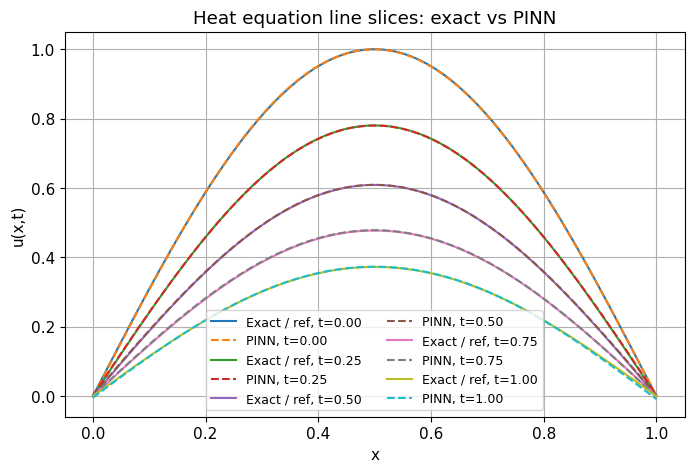

In [11]:
plot_line_slices(
    x_h,
    U_exact_h,
    U_pred_h,
    t_values=[0.0, 0.25, 0.5, 0.75, 1.0],
    t_grid=t_h,
    title_prefix="Heat equation line slices: exact vs PINN"
)

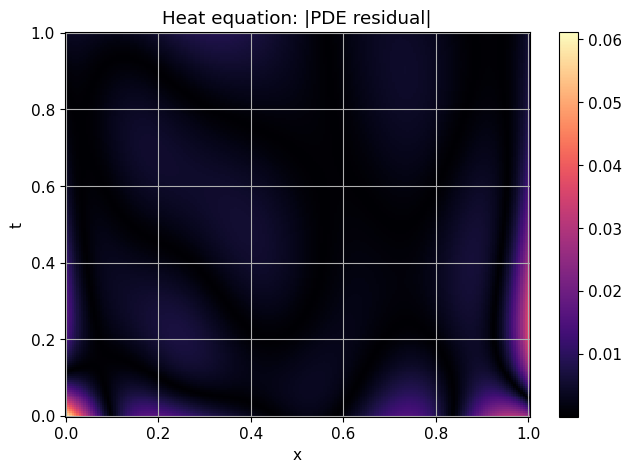

In [12]:
XT_h_res = make_tensor(XT_h)
r_h = heat_residual(heat_model, XT_h_res.clone(), heat_cfg.alpha)
R_h = np.abs(to_numpy(r_h)).reshape(T_h.shape)

plot_heatmap(X_h, T_h, R_h, "Heat equation: |PDE residual|", cmap="magma")

## 3. What changed in the inverse problem?

In the forward problem, the diffusion coefficient $\alpha$ was known.

In the inverse problem, we assume the PDE structure is known but $\alpha$ is unknown. We now train:
- the neural network weights $\theta$, and
- the scalar parameter $\alpha$

at the same time.

We also add a sparse set of observation points $(x_i,t_i,u_i^{obs})$. The loss becomes


$$
\mathcal{L} = \mathcal{L}_{res} + \mathcal{L}_{bc} + \mathcal{L}_{ic} + \lambda_d \mathcal{L}_{data},
$$


with


$$
\mathcal{L}_{data} = \frac{1}{N_d} \sum_i \left(u_\theta(x_i,t_i)-u_i^{obs}\right)^2.
$$


This is one of the main reasons PINNs are interesting: they can incorporate sparse data **and** enforce governing equations simultaneously.  

DeepXDE inverse diffusion demo: [link](https://deepxde.readthedocs.io/en/latest/demos/pinn_inverse/diffusion.1d.inverse.html)

In [13]:
@dataclass
class InverseHeatConfig:
    true_alpha: float = 0.10
    xmin: float = 0.0
    xmax: float = 1.0
    tmin: float = 0.0
    tmax: float = 1.0
    n_ic: int = 80
    n_bc: int = 80
    n_f: int = 2000
    n_data: int = 100
    noise_std: float = 0.00
    hidden_width: int = 64
    hidden_layers: int = 3
    epochs: int = 2500
    lr: float = 1e-3
    data_weight: float = 1.0

inv_cfg = InverseHeatConfig()
inv_cfg

InverseHeatConfig(true_alpha=0.1, xmin=0.0, xmax=1.0, tmin=0.0, tmax=1.0, n_ic=80, n_bc=80, n_f=2000, n_data=100, noise_std=0.0, hidden_width=64, hidden_layers=3, epochs=2500, lr=0.001, data_weight=1.0)

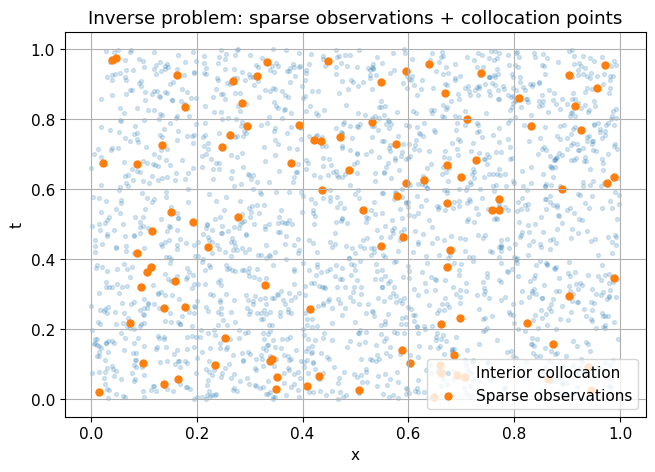

In [14]:
def generate_inverse_heat_data(cfg):
    x_ic = sample_uniform(cfg.n_ic, cfg.xmin, cfg.xmax)
    t_ic = np.zeros_like(x_ic)
    u_ic = exact_heat_solution(x_ic, t_ic, cfg.true_alpha)

    n_half = cfg.n_bc // 2
    t_bc_l = sample_uniform(n_half, cfg.tmin, cfg.tmax)
    x_bc_l = np.zeros_like(t_bc_l)
    u_bc_l = np.zeros_like(t_bc_l)

    t_bc_r = sample_uniform(cfg.n_bc - n_half, cfg.tmin, cfg.tmax)
    x_bc_r = np.ones_like(t_bc_r) * cfg.xmax
    u_bc_r = np.zeros_like(t_bc_r)

    x_bc = np.vstack([x_bc_l, x_bc_r])
    t_bc = np.vstack([t_bc_l, t_bc_r])
    u_bc = np.vstack([u_bc_l, u_bc_r])

    x_f = sample_uniform(cfg.n_f, cfg.xmin, cfg.xmax)
    t_f = sample_uniform(cfg.n_f, cfg.tmin, cfg.tmax)

    x_d = sample_uniform(cfg.n_data, cfg.xmin, cfg.xmax)
    t_d = sample_uniform(cfg.n_data, cfg.tmin, cfg.tmax)
    u_d = exact_heat_solution(x_d, t_d, cfg.true_alpha)
    if cfg.noise_std > 0:
        u_d = u_d + cfg.noise_std * np.random.randn(*u_d.shape)

    return {
        "x_ic": x_ic, "t_ic": t_ic, "u_ic": u_ic,
        "x_bc": x_bc, "t_bc": t_bc, "u_bc": u_bc,
        "x_f": x_f, "t_f": t_f,
        "x_d": x_d, "t_d": t_d, "u_d": u_d,
    }

inv_data = generate_inverse_heat_data(inv_cfg)

plt.figure(figsize=(7.5, 5))
plt.scatter(inv_data["x_f"], inv_data["t_f"], s=8, alpha=0.18, label="Interior collocation")
plt.scatter(inv_data["x_d"], inv_data["t_d"], s=25, label="Sparse observations")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Inverse problem: sparse observations + collocation points")
plt.legend()
plt.show()

In [15]:
class InverseHeatPINN(nn.Module):
    def __init__(self, width=64, depth=3, alpha_init=0.05):
        super().__init__()
        self.model = MLP(width=width, depth=depth)
        beta_init = np.log(np.exp(alpha_init) - 1.0)
        self.beta = nn.Parameter(torch.tensor([beta_init], dtype=torch.float32))

    @property
    def alpha(self):
        return torch.nn.functional.softplus(self.beta)

    def forward(self, x):
        return self.model(x)

def inverse_heat_residual(model, xt):
    xt.requires_grad_(True)
    u = model(xt)
    grads = gradients(u, xt)
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]
    u_xx = gradients(u_x, xt)[:, 0:1]
    return u_t - model.alpha * u_xx

def train_inverse_heat_pinn(cfg, data):
    model = InverseHeatPINN(
        width=cfg.hidden_width,
        depth=cfg.hidden_layers,
        alpha_init=0.05
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    xt_ic = make_xt(data["x_ic"], data["t_ic"])
    u_ic = make_tensor(data["u_ic"])

    xt_bc = make_xt(data["x_bc"], data["t_bc"])
    u_bc = make_tensor(data["u_bc"])

    xt_f = make_xt(data["x_f"], data["t_f"])

    xt_d = make_xt(data["x_d"], data["t_d"])
    u_d = make_tensor(data["u_d"])

    history = {
        "total": [], "residual": [], "ic": [], "bc": [], "data": [], "alpha": []
    }

    for epoch in range(cfg.epochs):
        opt.zero_grad()

        pred_ic = model(xt_ic)
        pred_bc = model(xt_bc)
        pred_d = model(xt_d)

        r = inverse_heat_residual(model, xt_f.clone())

        loss_ic = mse(pred_ic, u_ic)
        loss_bc = mse(pred_bc, u_bc)
        loss_data = mse(pred_d, u_d)
        loss_res = torch.mean(r**2)

        loss = loss_ic + loss_bc + loss_res + cfg.data_weight * loss_data
        loss.backward()
        opt.step()

        history["total"].append(loss.item())
        history["residual"].append(loss_res.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())
        history["data"].append(loss_data.item())
        history["alpha"].append(model.alpha.item())

        if (epoch + 1) % 250 == 0:
            print(
                f"Epoch {epoch+1:5d} | total={loss.item():.3e} | "
                f"res={loss_res.item():.3e} | data={loss_data.item():.3e} | "
                f"alpha={model.alpha.item():.5f}"
            )

    return model, history

inv_model, inv_history = train_inverse_heat_pinn(inv_cfg, inv_data)

Epoch   250 | total=4.770e-03 | res=8.225e-04 | data=3.228e-03 | alpha=0.06348
Epoch   500 | total=1.566e-03 | res=3.621e-04 | data=9.612e-04 | alpha=0.07924
Epoch   750 | total=3.889e-04 | res=1.464e-04 | data=1.488e-04 | alpha=0.09081
Epoch  1000 | total=1.280e-04 | res=8.755e-05 | data=2.583e-05 | alpha=0.09692
Epoch  1250 | total=7.959e-05 | res=6.743e-05 | data=3.399e-06 | alpha=0.09914
Epoch  1500 | total=6.104e-05 | res=5.266e-05 | data=1.076e-06 | alpha=0.09974
Epoch  1750 | total=4.205e-05 | res=3.646e-05 | data=1.123e-06 | alpha=0.09991
Epoch  2000 | total=3.160e-05 | res=2.764e-05 | data=5.209e-07 | alpha=0.09995
Epoch  2250 | total=2.555e-05 | res=2.235e-05 | data=3.740e-07 | alpha=0.09997
Epoch  2500 | total=1.755e-05 | res=1.577e-05 | data=2.240e-07 | alpha=0.09998


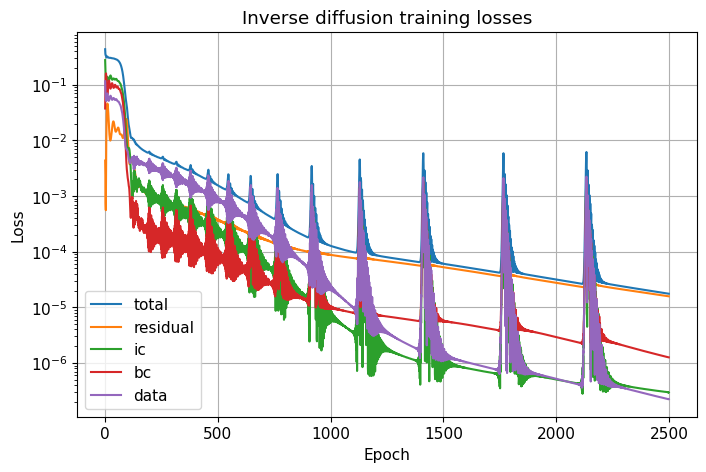

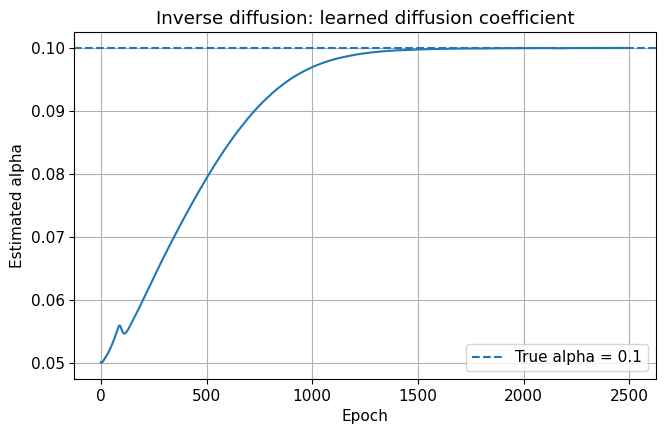

True alpha    : 0.1
Estimated alpha: 0.09998117387294769


In [16]:
plot_losses(
    {k: v for k, v in inv_history.items() if k != "alpha"},
    title="Inverse diffusion training losses"
)

plt.figure(figsize=(7.5, 4.5))
plt.plot(inv_history["alpha"])
plt.axhline(inv_cfg.true_alpha, linestyle="--", label=f"True alpha = {inv_cfg.true_alpha}")
plt.xlabel("Epoch")
plt.ylabel("Estimated alpha")
plt.title("Inverse diffusion: learned diffusion coefficient")
plt.legend()
plt.show()

print("True alpha    :", inv_cfg.true_alpha)
print("Estimated alpha:", inv_model.alpha.item())

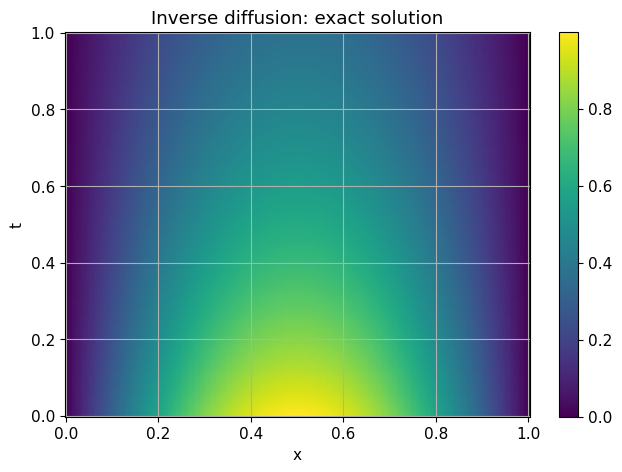

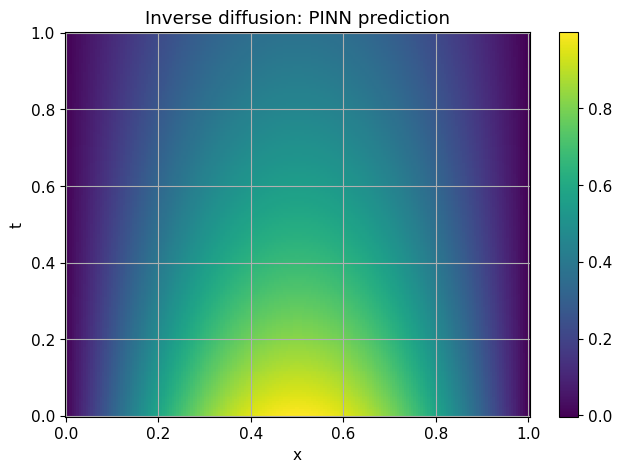

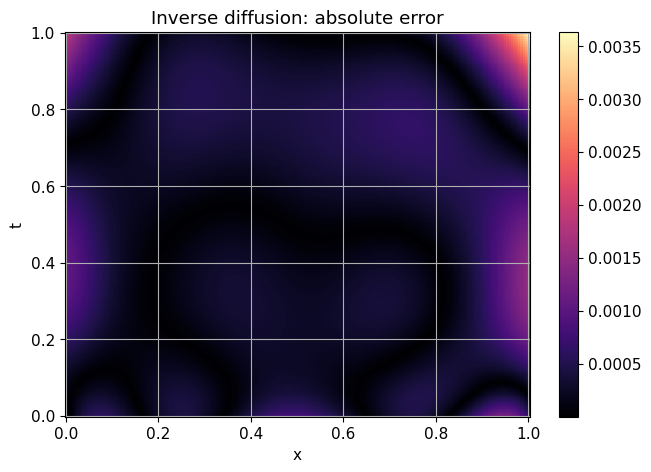

In [17]:
x_i, t_i, X_i, T_i, XT_i = meshgrid_eval(
    inv_cfg.xmin, inv_cfg.xmax,
    inv_cfg.tmin, inv_cfg.tmax,
    nx=200, nt=200
)

XT_i_t = make_tensor(XT_i)
with torch.no_grad():
    U_pred_i = to_numpy(inv_model(XT_i_t)).reshape(T_i.shape)

U_exact_i = exact_heat_solution(X_i, T_i, inv_cfg.true_alpha)
U_err_i = np.abs(U_pred_i - U_exact_i)

plot_heatmap(X_i, T_i, U_exact_i, "Inverse diffusion: exact solution")
plot_heatmap(X_i, T_i, U_pred_i, "Inverse diffusion: PINN prediction")
plot_heatmap(X_i, T_i, U_err_i, "Inverse diffusion: absolute error", cmap="magma")

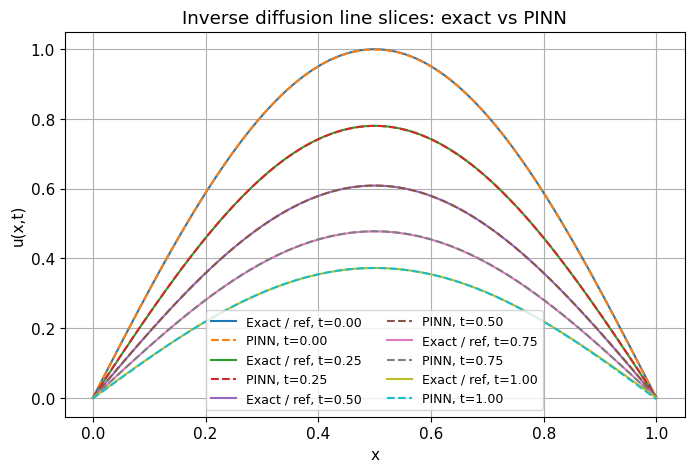

In [18]:
plot_line_slices(
    x_i,
    U_exact_i,
    U_pred_i,
    t_values=[0.0, 0.25, 0.5, 0.75, 1.0],
    t_grid=t_i,
    title_prefix="Inverse diffusion line slices: exact vs PINN"
)

## 4. Burgers' equation: a standard nonlinear PINN benchmark

To move beyond pure diffusion, we now consider the 1D viscous Burgers equation

$$
u_t + u u_x - \nu u_{xx} = 0
$$

on a space-time domain $x \in [-1,1]$, $t \in [0,1]$, with

$$
u(x,0) = -\sin(\pi x), \qquad u(-1,t)=u(1,t)=0.
$$

This is one of the canonical nonlinear benchmark problems in the PINN literature and in DeepXDE tutorials.  
DeepXDE Burgers tutorial for a framework-based implementation of the same style of problem: [link](https://deepxde.readthedocs.io/en/stable/demos/pinn_forward/burgers.html)

### Why Burgers is harder than the heat equation
The heat equation is linear in $u$. Burgers adds the nonlinear term $u u_x$, which creates steeper gradients and a harder optimization problem for the PINN. This is one reason later PINN literature puts substantial emphasis on training pathologies, loss balancing, and other stabilization strategies.  


In [19]:
@dataclass
class BurgersConfig:
    nu: float = 0.01 / np.pi
    xmin: float = -1.0
    xmax: float = 1.0
    tmin: float = 0.0
    tmax: float = 1.0
    n_ic: int = 200
    n_bc: int = 200
    n_f: int = 4000
    hidden_width: int = 64
    hidden_layers: int = 4
    epochs: int = 2500
    lr: float = 1e-3
    nx_ref: int = 201
    nt_ref: int = 101

burg_cfg = BurgersConfig()
burg_cfg

BurgersConfig(nu=0.003183098861837907, xmin=-1.0, xmax=1.0, tmin=0.0, tmax=1.0, n_ic=200, n_bc=200, n_f=4000, hidden_width=64, hidden_layers=4, epochs=2500, lr=0.001, nx_ref=201, nt_ref=101)

### About the Burgers "reference solution"

For the heat equation, we have a closed-form exact solution.

For Burgers' equation in this notebook, we instead build a **numerical reference solution** using a classical method:
- finite differences in space, then
- `scipy.integrate.solve_ivp` in time

That means the Burgers comparison below is **PINN vs a numerical reference solution**, not PINN vs an analytic closed-form formula.


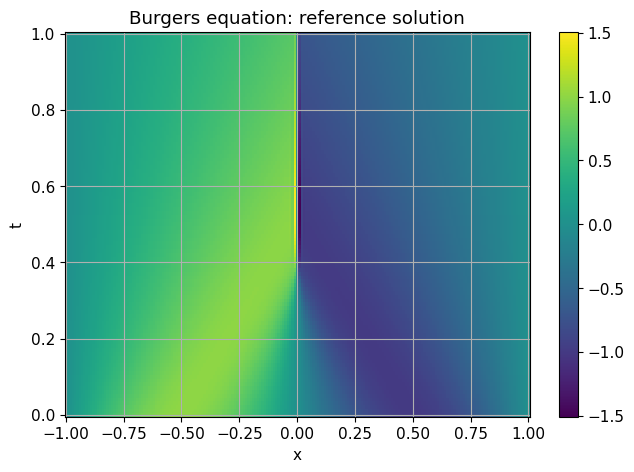

In [20]:
def burgers_reference_solution(cfg):
    x = np.linspace(cfg.xmin, cfg.xmax, cfg.nx_ref)
    t_eval = np.linspace(cfg.tmin, cfg.tmax, cfg.nt_ref)
    dx = x[1] - x[0]

    u0 = -np.sin(np.pi * x)
    u0[0] = 0.0
    u0[-1] = 0.0

    def rhs(t, u):
        dudt = np.zeros_like(u)
        dudt[0] = 0.0
        dudt[-1] = 0.0

        u_x = (u[2:] - u[:-2]) / (2 * dx)
        u_xx = (u[2:] - 2 * u[1:-1] + u[:-2]) / dx**2
        dudt[1:-1] = -u[1:-1] * u_x + cfg.nu * u_xx
        return dudt

    sol = solve_ivp(
        rhs,
        (cfg.tmin, cfg.tmax),
        u0,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-6,
        atol=1e-8,
    )
    U = sol.y.T
    U[:, 0] = 0.0
    U[:, -1] = 0.0
    return x, t_eval, U

x_ref_b, t_ref_b, U_ref_b = burgers_reference_solution(burg_cfg)

X_ref_b, T_ref_b = np.meshgrid(x_ref_b, t_ref_b)
plot_heatmap(X_ref_b, T_ref_b, U_ref_b, "Burgers equation: reference solution")

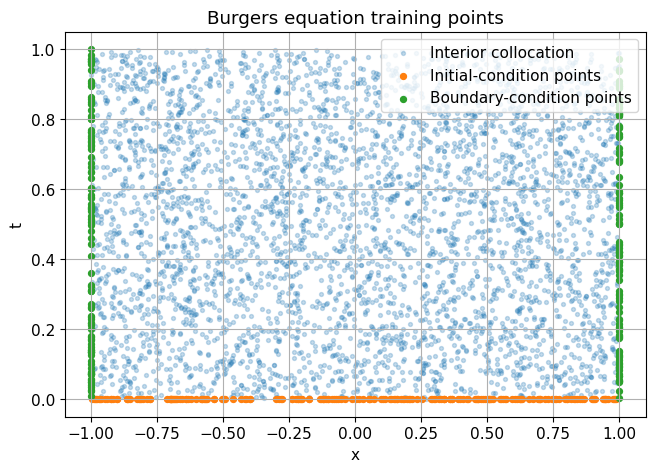

In [21]:
def generate_burgers_training_data(cfg):
    x_ic = sample_uniform(cfg.n_ic, cfg.xmin, cfg.xmax)
    t_ic = np.zeros_like(x_ic)
    u_ic = -np.sin(np.pi * x_ic)

    n_half = cfg.n_bc // 2
    t_bc_l = sample_uniform(n_half, cfg.tmin, cfg.tmax)
    x_bc_l = np.ones_like(t_bc_l) * cfg.xmin
    u_bc_l = np.zeros_like(t_bc_l)

    t_bc_r = sample_uniform(cfg.n_bc - n_half, cfg.tmin, cfg.tmax)
    x_bc_r = np.ones_like(t_bc_r) * cfg.xmax
    u_bc_r = np.zeros_like(t_bc_r)

    x_bc = np.vstack([x_bc_l, x_bc_r])
    t_bc = np.vstack([t_bc_l, t_bc_r])
    u_bc = np.vstack([u_bc_l, u_bc_r])

    x_f = sample_uniform(cfg.n_f, cfg.xmin, cfg.xmax)
    t_f = sample_uniform(cfg.n_f, cfg.tmin, cfg.tmax)

    return {
        "x_ic": x_ic, "t_ic": t_ic, "u_ic": u_ic,
        "x_bc": x_bc, "t_bc": t_bc, "u_bc": u_bc,
        "x_f": x_f, "t_f": t_f,
    }

burg_data = generate_burgers_training_data(burg_cfg)
scatter_training_points(
    burg_data["x_ic"], burg_data["t_ic"],
    burg_data["x_bc"], burg_data["t_bc"],
    burg_data["x_f"], burg_data["t_f"],
    "Burgers equation training points"
)

In [22]:
def burgers_residual(model, xt, nu):
    xt.requires_grad_(True)
    u = model(xt)
    grads = gradients(u, xt)
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]
    u_xx = gradients(u_x, xt)[:, 0:1]
    return u_t + u * u_x - nu * u_xx

def train_burgers_pinn(cfg, data):
    model = MLP(width=cfg.hidden_width, depth=cfg.hidden_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    xt_ic = make_xt(data["x_ic"], data["t_ic"])
    u_ic = make_tensor(data["u_ic"])

    xt_bc = make_xt(data["x_bc"], data["t_bc"])
    u_bc = make_tensor(data["u_bc"])

    xt_f = make_xt(data["x_f"], data["t_f"])

    history = {"total": [], "residual": [], "ic": [], "bc": []}

    for epoch in range(cfg.epochs):
        opt.zero_grad()

        pred_ic = model(xt_ic)
        pred_bc = model(xt_bc)
        r = burgers_residual(model, xt_f.clone(), cfg.nu)

        loss_ic = mse(pred_ic, u_ic)
        loss_bc = mse(pred_bc, u_bc)
        loss_res = torch.mean(r**2)
        loss = loss_ic + loss_bc + loss_res

        loss.backward()
        opt.step()

        history["total"].append(loss.item())
        history["residual"].append(loss_res.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())

        if (epoch + 1) % 250 == 0:
            print(
                f"Epoch {epoch+1:5d} | total={loss.item():.3e} | "
                f"res={loss_res.item():.3e} | ic={loss_ic.item():.3e} | bc={loss_bc.item():.3e}"
            )

    return model, history

burg_model, burg_history = train_burgers_pinn(burg_cfg, burg_data)

Epoch   250 | total=1.369e-01 | res=5.029e-02 | ic=7.974e-02 | bc=6.900e-03
Epoch   500 | total=1.335e-01 | res=4.519e-02 | ic=8.026e-02 | bc=8.098e-03
Epoch   750 | total=8.932e-02 | res=3.693e-02 | ic=5.198e-02 | bc=4.132e-04
Epoch  1000 | total=8.623e-02 | res=3.414e-02 | ic=5.167e-02 | bc=4.257e-04
Epoch  1250 | total=8.287e-02 | res=3.317e-02 | ic=4.933e-02 | bc=3.667e-04
Epoch  1500 | total=7.936e-02 | res=3.189e-02 | ic=4.718e-02 | bc=2.967e-04
Epoch  1750 | total=7.533e-02 | res=3.035e-02 | ic=4.471e-02 | bc=2.710e-04
Epoch  2000 | total=7.067e-02 | res=2.796e-02 | ic=4.247e-02 | bc=2.364e-04
Epoch  2250 | total=6.826e-02 | res=2.371e-02 | ic=4.358e-02 | bc=9.745e-04
Epoch  2500 | total=5.778e-02 | res=2.236e-02 | ic=3.514e-02 | bc=2.799e-04


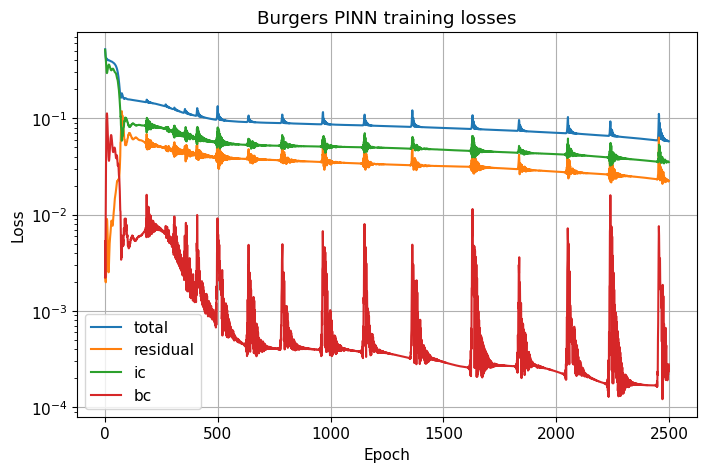

In [23]:
plot_losses(burg_history, title="Burgers PINN training losses")

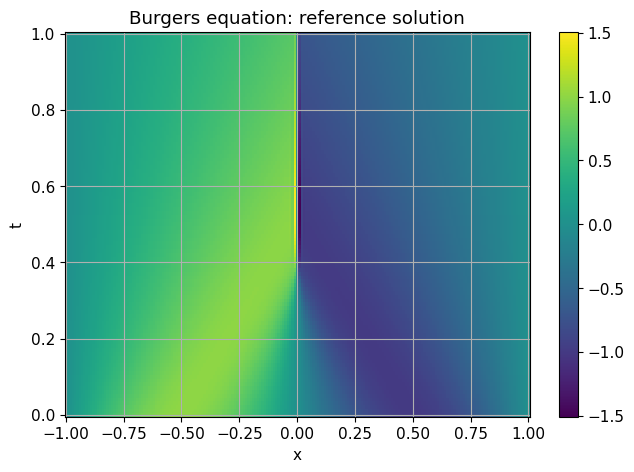

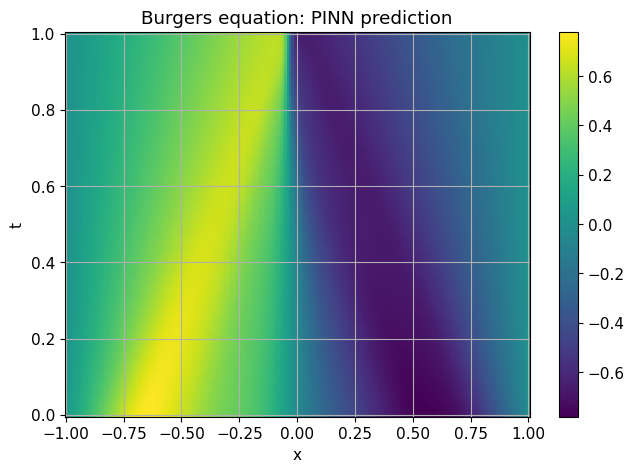

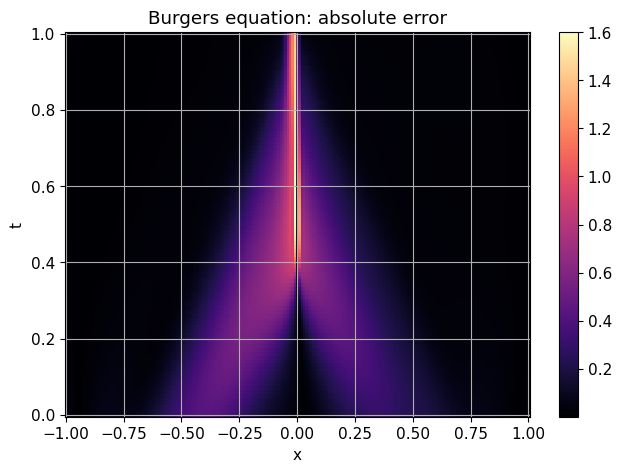

In [24]:
XT_b = np.column_stack([X_ref_b.ravel(), T_ref_b.ravel()])
XT_b_t = make_tensor(XT_b)

with torch.no_grad():
    U_pred_b = to_numpy(burg_model(XT_b_t)).reshape(U_ref_b.shape)

U_err_b = np.abs(U_pred_b - U_ref_b)

plot_heatmap(X_ref_b, T_ref_b, U_ref_b, "Burgers equation: reference solution")
plot_heatmap(X_ref_b, T_ref_b, U_pred_b, "Burgers equation: PINN prediction")
plot_heatmap(X_ref_b, T_ref_b, U_err_b, "Burgers equation: absolute error", cmap="magma")

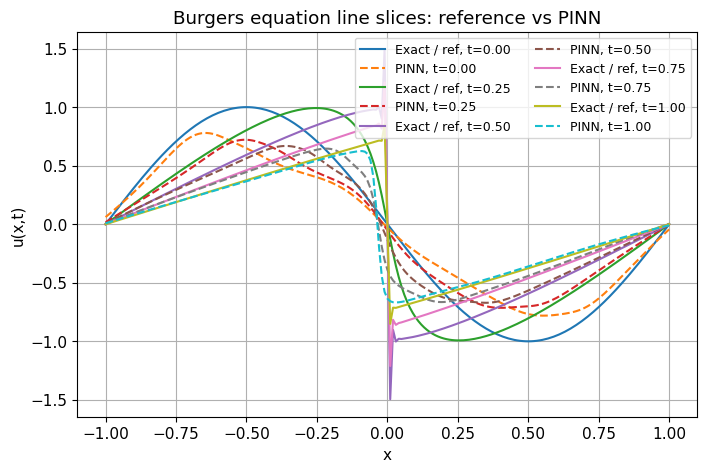

In [25]:
plot_line_slices(
    x_ref_b,
    U_ref_b,
    U_pred_b,
    t_values=[0.0, 0.25, 0.5, 0.75, 1.0],
    t_grid=t_ref_b,
    title_prefix="Burgers equation line slices: reference vs PINN"
)

## 5. Side-by-side summary

The three examples in this notebook illustrate a natural PINN progression:

| Problem | Unknowns being learned | Loss terms | Main point |
|---|---|---|---|
| Heat equation | solution $u(x,t)$ | residual + BC + IC | basic forward PINN workflow |
| Inverse diffusion | solution $u(x,t)$, coefficient $\alpha$ | residual + BC + IC + data | parameter identification from sparse data |
| Burgers | solution $u(x,t)$ | residual + BC + IC | nonlinear PINN benchmark |

### Key takeaways
1. PINNs use a neural network as a function approximator **plus** a physics residual in the loss.  
2. The interior collocation points are where the PDE is enforced.  
3. Inverse problems are often an especially natural use case because the model can combine sparse measurements with known governing equations.  
4. Nonlinear PDEs can be substantially harder to train than simple diffusion problems.

### A caveat
PINNs are elegant and flexible, but they are not automatically superior to classical solvers. Later reviews and benchmarking studies emphasize training pathologies, loss balancing issues, and cases where classical methods such as finite elements remain much more efficient for standard forward PDE solves:    T. Grossmann et al., *Can physics-informed neural networks beat the finite element method?*, 2024.[https://academic.oup.com/imamat/article/89/1/143/7680268](https://academic.oup.com/imamat/article/89/1/143/7680268)  



## AI disclosure statement
This notebook was developed with assistance from ChatGPT; the authors maintain full responsibility for its content